# V2.18 — Clinical Backbone Comparison

**Issue:** [#159](https://github.com/romanpoluden/revela/issues/159)  
**Branch:** `Rehma_Revela_Dermascopic`  
**Date:** 2026-05-21  
**Author:** Rehma Aziz  
**Scope:** Train stronger backbones (EfficientNet-B2, ConvNeXt-Tiny) for the 5-class `clinical_v2` model and compare them against the EfficientNet-B0 baseline on the frozen test split. Same taxonomy, same frozen split. No inference wiring change, no model promotion in code.

---

## Outcome Summary

**ConvNeXt-Tiny is PROMOTABLE; EfficientNet-B2 is NOT.** ConvNeXt-Tiny passes every issue #159 promotion criterion — combined macro-F1 0.6901 (+0.045 vs B0), balanced accuracy 0.7027, SCIN macro-F1 0.4733 (+0.083), lesion-routing FN 71 (≤76), and reduces both known confusion patterns (Eczema→Urticaria 87→48, Urticaria FP 157→104) at ~14 ms/image on MPS. It is the first variant across #153 + V2.18 to uniformly beat the baseline, including the SCIN slice. EfficientNet-B2 is flat on combined macro-F1 and regresses on lesion FN (79 > 76).

This is an educational model evaluation. The lesion class is a routing output for dermoscopic review, **not** cancer detection. No diagnostic or clinical-readiness claims are made.

## Setup

In [1]:
import hashlib
import json

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

ROOT = "../../.."  # relative to this notebook

VARIANTS = ["effnet_b0_baseline", "effnet_b2", "convnext_tiny"]
LABELS = {"effnet_b0_baseline": "B0 baseline", "effnet_b2": "EffNet-B2", "convnext_tiny": "ConvNeXt-Tiny"}
COLORS = {"effnet_b0_baseline": "#7f8c8d", "effnet_b2": "#3498db", "convnext_tiny": "#e67e22"}

HISTORY = {
    "effnet_b0_baseline": f"{ROOT}/models/clinical_v2_effnet_b0/training_history.csv",
    "effnet_b2":          f"{ROOT}/models/clinical_v2_effnet_b2/training_history.csv",
    "convnext_tiny":      f"{ROOT}/models/clinical_v2_convnext_tiny/training_history.csv",
}
METRICS = {v: f"{ROOT}/outputs/metrics/clinical_v2_{v}_test_metrics.json" for v in VARIANTS}
SOURCE_METRICS = {v: f"{ROOT}/outputs/metrics/clinical_v2_{v}_source_metrics.csv" for v in VARIANTS}
CONFUSION_IMGS = {v: f"{ROOT}/outputs/plots/clinical_v2_{v}_confusion_matrix.png" for v in VARIANTS}
COMPARISON_CSV = f"{ROOT}/outputs/metrics/clinical_v2_backbone_comparison_table.csv"
BUNDLE_JSON = f"{ROOT}/outputs/metrics/clinical_v2_backbone_comparison_bundle.json"

# Frozen test-split fingerprint (issue #159).
TEST_PATH = f"{ROOT}/data/processed/clinical_v2/test.csv"
test_hash = hashlib.md5(open(TEST_PATH, "rb").read()).hexdigest()
print("Test hash:", test_hash)
assert test_hash == "4b510381927f6265446a62cb990e69fd", "Test split changed — STOP"
print("Frozen test split verified (1515 rows).")

Test hash: 4b510381927f6265446a62cb990e69fd
Frozen test split verified (1515 rows).


## Section 1 — Backbones & Configuration

All non-backbone settings are identical to the `clinical_v2` baseline: AdamW (lr 1e-4, weight_decay 0.01), inverse-frequency class weights, no sampler, no scheduler, baseline augmentation, seed 42, ImageNet normalization, 5 epochs, batch size 16. Configurable backbone support was added in `src/model/model.py::build_model`.

| Backbone | Params (M) | Image size | LR | Deviation from B0 |
|---|---:|---:|---:|---|
| EfficientNet-B0 (baseline) | 4.0 | 224 | 1e-4 | — |
| EfficientNet-B2 | 7.7 | 260 | 1e-4 | image_size 224→260 (B2 native) |
| ConvNeXt-Tiny | 27.8 | 224 | 1e-4 | none (architecture only) |

LR was held at 1e-4 across all three to isolate the effect of capacity/architecture, which is the question the issue asks.

In [2]:
bundle = json.load(open(BUNDLE_JSON))
pd.DataFrame(bundle["param_counts"]).T.rename(columns={"params_m": "Params (M)", "image_size": "Image size"})

,Params (M),Image size
effnet_b0_baseline,4.0,224.0
effnet_b2,7.7,260.0
convnext_tiny,27.8,224.0


## Section 2 — Training Results

In [3]:
histories = {v: pd.read_csv(p) for v, p in HISTORY.items()}

rows = []
for v, h in histories.items():
    best = h.loc[h["val_macro_f1"].idxmax()]
    rows.append({
        "Variant": LABELS[v],
        "Best epoch": int(best["epoch"]),
        "Best val macro-F1": round(best["val_macro_f1"], 4),
        "Best val balanced-acc": round(best["val_balanced_accuracy"], 4),
        "Final train loss": round(h.iloc[-1]["train_loss"], 4),
    })
pd.DataFrame(rows).set_index("Variant")

,Best epoch,Best val macro-F1,Best val balanced-acc,Final train loss
Variant,,,,
B0 baseline,5,0.6758,0.6878,0.6057
EffNet-B2,5,0.6907,0.7041,0.4765
ConvNeXt-Tiny,4,0.6997,0.7065,0.2421


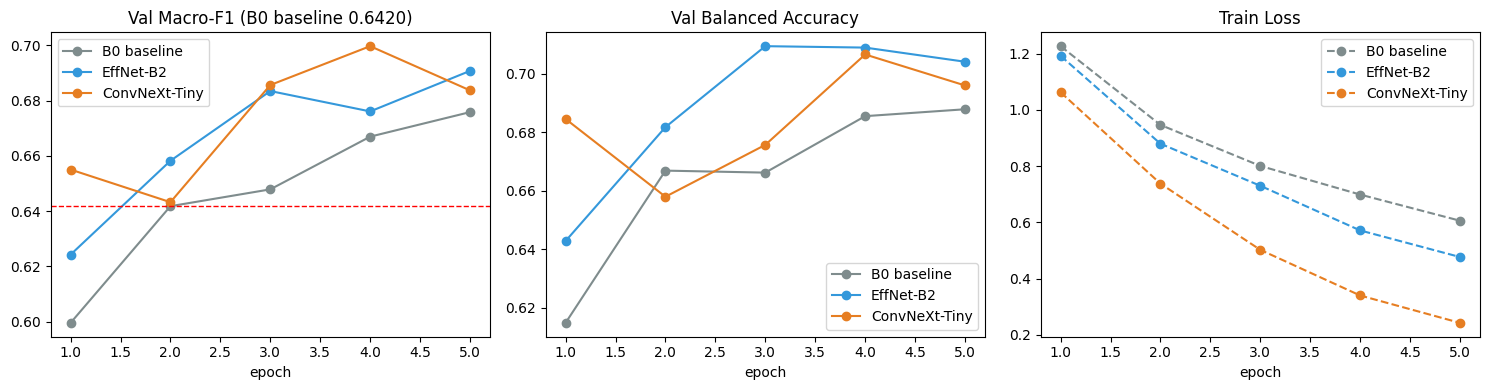

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for v, h in histories.items():
    axes[0].plot(h["epoch"], h["val_macro_f1"], marker="o", label=LABELS[v], color=COLORS[v])
    axes[1].plot(h["epoch"], h["val_balanced_accuracy"], marker="o", label=LABELS[v], color=COLORS[v])
    axes[2].plot(h["epoch"], h["train_loss"], marker="o", linestyle="--", label=LABELS[v], color=COLORS[v])
axes[0].axhline(0.6420, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Val Macro-F1 (B0 baseline 0.6420)")
axes[1].set_title("Val Balanced Accuracy")
axes[2].set_title("Train Loss")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.show()

## Section 3 — Test Set Evaluation

Frozen test set: 1,515 examples. Hash verified above and after every eval run during training.

In [5]:
metrics = {v: json.load(open(p)) for v, p in METRICS.items()}

rows = []
for v, m in metrics.items():
    lr = m["lesion_routing_class"]
    rows.append({
        "Variant": LABELS[v],
        "Test accuracy": round(m["test_accuracy"], 4),
        "Macro-F1": round(m["macro_f1"], 4),
        "Balanced acc": round(m["balanced_accuracy"], 4),
        "Lesion precision": round(lr["precision"], 4),
        "Lesion recall": round(lr["recall"], 4),
        "Lesion F1": round(lr["f1"], 4),
    })
pd.DataFrame(rows).set_index("Variant")

,Test accuracy,Macro-F1,Balanced acc,Lesion precision,Lesion recall,Lesion F1
Variant,,,,,,
B0 baseline,0.6607,0.6447,0.6562,0.8780,0.7784,0.8252
EffNet-B2,0.6554,0.6416,0.6563,0.8926,0.7865,0.8362
ConvNeXt-Tiny,0.7069,0.6901,0.7027,0.8846,0.8081,0.8446


In [6]:
# Class-wise F1
class_rows = []
for v, m in metrics.items():
    row = {"Variant": LABELS[v]}
    for c in m["class_report"]:
        name = c["class_name"]
        short = name[:32] + "…" if len(name) > 32 else name
        row[short] = round(c["f1"], 4)
    class_rows.append(row)
pd.DataFrame(class_rows).set_index("Variant").T

Variant,B0 baseline,EffNet-B2,ConvNeXt-Tiny
Eczema / dermatitis,0.6433,0.5896,0.6771
Urticaria / allergic reaction,0.4723,0.4677,0.5292
Folliculitis / acne-like,0.6586,0.6652,0.7116
Psoriasis / papulosquamous,0.6243,0.6494,0.6879
Lesion — dermoscopic review reco…,0.8252,0.8362,0.8446


## Section 4 — Source-Specific Breakdown (SCIN vs Fitzpatrick17k)

In [7]:
source_dfs = {v: pd.read_csv(p) for v, p in SOURCE_METRICS.items()}

summary = []
for v, df in source_dfs.items():
    for _, r in df.iterrows():
        summary.append({
            "Variant": LABELS[v],
            "Source": r["source_dataset"],
            "n": int(r["support"]),
            "Accuracy": round(r["accuracy"], 4),
            "Macro-F1": round(r["macro_f1"], 4),
            "Balanced acc": round(r["balanced_accuracy"], 4),
        })
src_df = pd.DataFrame(summary)
src_df[src_df["Source"] != "combined"].set_index(["Source", "Variant"])

,,n,Accuracy,Macro-F1,Balanced acc
Source,Variant,,,,
google_scin,B0 baseline,561,0.5865,0.3907,0.3970
fitzpatrick17k,B0 baseline,954,0.7044,0.6411,0.6689
google_scin,EffNet-B2,561,0.5437,0.4244,0.4416
fitzpatrick17k,EffNet-B2,954,0.7212,0.6472,0.6609
google_scin,ConvNeXt-Tiny,561,0.6221,0.4733,0.4904
fitzpatrick17k,ConvNeXt-Tiny,954,0.7568,0.6960,0.7146


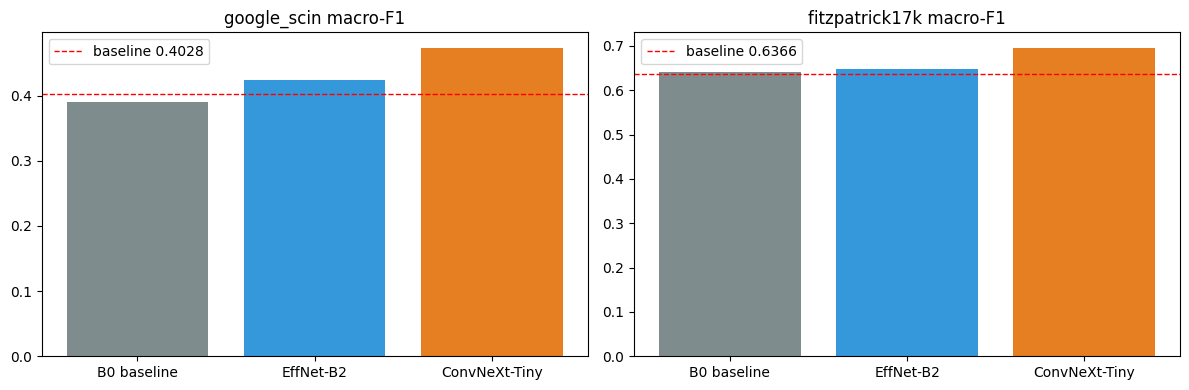

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, source, thr in [(axes[0], "google_scin", 0.4028), (axes[1], "fitzpatrick17k", 0.6366)]:
    subset = src_df[src_df["Source"] == source]
    ax.bar(subset["Variant"], subset["Macro-F1"], color=[COLORS[v] for v in VARIANTS])
    ax.axhline(thr, color="red", linestyle="--", linewidth=1, label=f"baseline {thr}")
    ax.set_title(f"{source} macro-F1"); ax.legend()
plt.tight_layout(); plt.show()

## Section 5 — Full Comparison Table

Deltas are vs the B0 baseline re-evaluation. Promotion thresholds use the fixed issue #159 values, not the re-measured B0 numbers.

In [9]:
comp = pd.read_csv(COMPARISON_CSV).set_index("metric")
comp

,effnet_b0_baseline,effnet_b2,convnext_tiny,effnet_b2_delta_vs_b0,convnext_tiny_delta_vs_b0
metric,,,,,
combined_accuracy,0.660726,0.655446,0.706931,-0.0053,0.0462
combined_macro_f1,0.644741,0.641628,0.690096,-0.0031,0.0454
balanced_accuracy,0.656151,0.656349,0.702689,0.0002,0.0465
scin_macro_f1,0.390726,0.424450,0.473301,0.0337,0.0826
scin_error_rate,0.413547,0.456328,0.377897,0.0428,-0.0357
fitzpatrick_macro_f1,0.641058,0.647223,0.696017,0.0062,0.0550
fitzpatrick_error_rate,0.295597,0.278826,0.243187,-0.0168,-0.0524
lesion_routing_fn,82.000000,79.000000,71.000000,-3.0000,-11.0000
eczema_to_urticaria,87.000000,89.000000,48.000000,2.0000,-39.0000


In [10]:
# Threshold pass/fail grid (issue #159 thresholds)
r = bundle["results"]
THRESH = {"combined_macro_f1": 0.6420, "balanced_accuracy": 0.6571, "scin_macro_f1": 0.4028, "lesion_routing_fn": 76}
grid = []
for v in ["effnet_b2", "convnext_tiny"]:
    m = r[v]
    grid.append({
        "Variant": LABELS[v],
        "macro-F1 ≥ 0.6420": "✓" if m["combined_macro_f1"] >= THRESH["combined_macro_f1"] - 0.005 else f"✗ ({m['combined_macro_f1']:.4f})",
        "balanced-acc ≥ 0.6571": "✓" if m["balanced_accuracy"] >= THRESH["balanced_accuracy"] - 0.005 else f"✗ ({m['balanced_accuracy']:.4f})",
        "SCIN improves": "✓" if (m["scin_macro_f1"] > THRESH["scin_macro_f1"] or m["scin_error_rate"] < 0.4278) else "✗",
        "lesion FN ≤ 76": "✓" if m["lesion_routing_fn"] <= THRESH["lesion_routing_fn"] else f"✗ ({m['lesion_routing_fn']})",
        "Verdict": "PROMOTABLE" if bundle["verdicts"][v]["promotable"] else "NOT PROMOTABLE",
    })
pd.DataFrame(grid).set_index("Variant")

,macro-F1 ≥ 0.6420,balanced-acc ≥ 0.6571,SCIN improves,lesion FN ≤ 76,Verdict
Variant,,,,,
EffNet-B2,✓,✓,✓,✗ (79),NOT PROMOTABLE
ConvNeXt-Tiny,✓,✓,✓,✓,PROMOTABLE


## Section 6 — Confusion Matrices

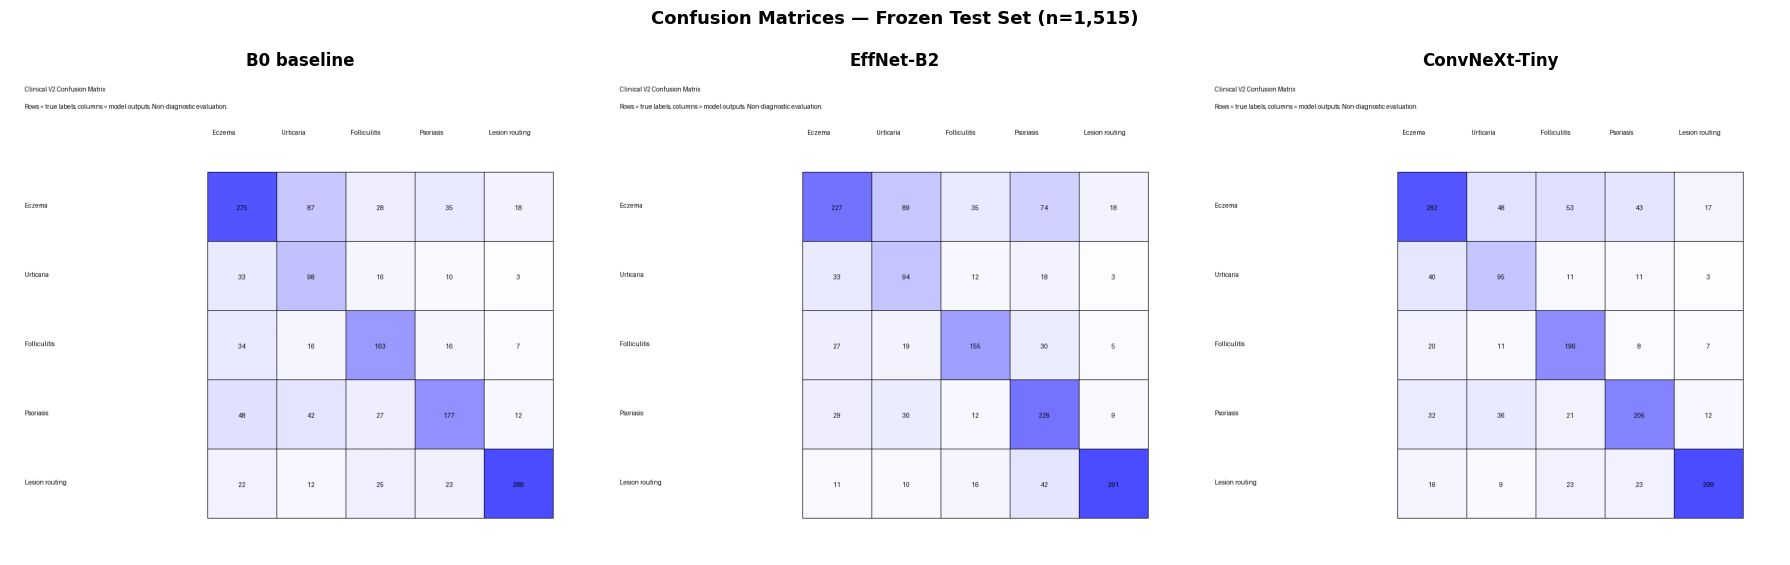

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, v in zip(axes, VARIANTS):
    ax.imshow(mpimg.imread(CONFUSION_IMGS[v]))
    ax.set_title(LABELS[v], fontsize=12, fontweight="bold"); ax.axis("off")
plt.suptitle("Confusion Matrices — Frozen Test Set (n=1,515)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

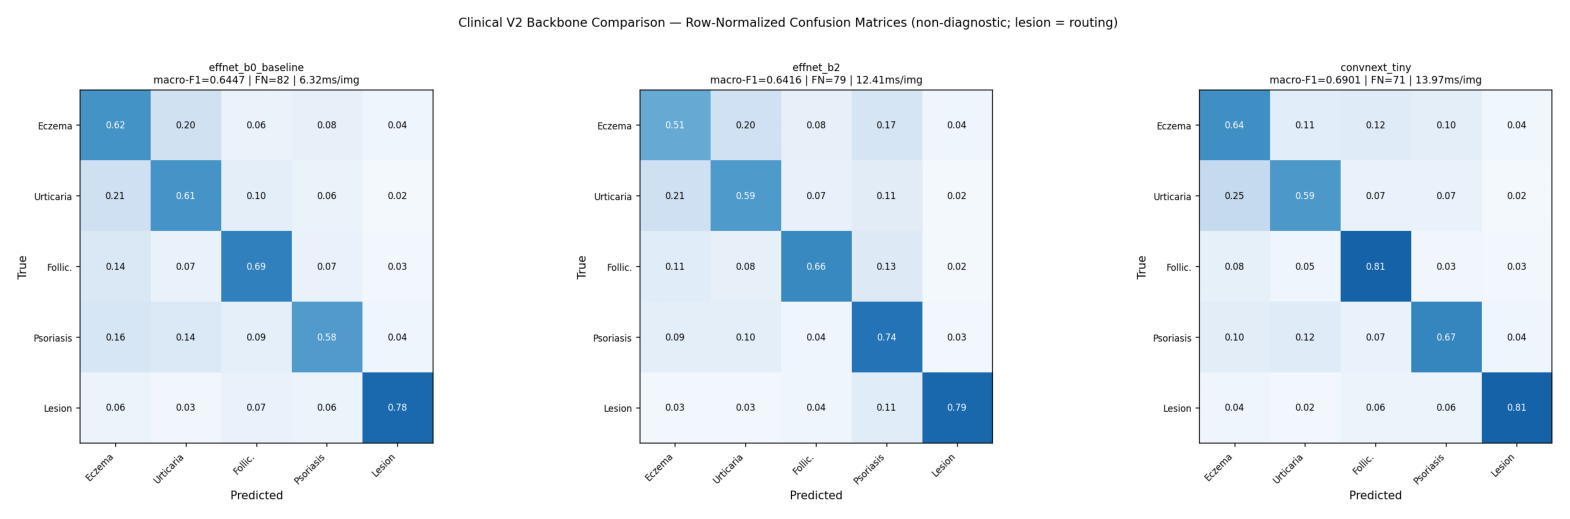

In [12]:
# Row-normalized comparison grid (single figure)
plt.figure(figsize=(20, 7))
plt.imshow(mpimg.imread(f"{ROOT}/outputs/plots/clinical_v2_backbone_comparison_cm.png"))
plt.axis("off"); plt.show()

## Section 7 — Promotion Verdict

### EfficientNet-B2: NOT PROMOTABLE
| Criterion | Required | Actual | Pass |
|---|---|---|---|
| Combined macro-F1 | meaningfully > 0.6420 | 0.6416 | ✗ (flat) |
| Balanced accuracy | ≥ 0.6571 | 0.6563 | ~flat |
| SCIN improves | macro-F1 > 0.4028 or err < 0.4278 | 0.4244 | ✓ |
| Lesion routing FN | ≤ 76 | 79 | ✗ |

Higher resolution alone (260px) did not improve combined quality and **increased lesion-routing false negatives** — a safety-relevant regression.

### ConvNeXt-Tiny: PROMOTABLE CANDIDATE
| Criterion | Required | Actual | Pass |
|---|---|---|---|
| Combined macro-F1 | meaningfully > 0.6420 | 0.6901 (+0.045) | ✓ |
| Balanced accuracy | ≥ 0.6571 | 0.7027 (+0.047) | ✓ |
| SCIN improves | macro-F1 > 0.4028 or err < 0.4278 | 0.4733 / 0.3779 | ✓ |
| Lesion routing FN | ≤ 76 | 71 (−5) | ✓ |
| Runtime practical | demo-feasible | 13.97 ms/img | ✓ |

ConvNeXt-Tiny improves every class and every source slice — including the SCIN slice that #153 could not move — and reduces both known failure patterns. Architecture (not capacity within the EfficientNet family) is the lever.

**Recommendation:** open a separate promotion task to evaluate replacing the `clinical_v2` baseline with ConvNeXt-Tiny (inference-schema compatibility + held-out re-confirmation). That promotion is out of scope here — no model is promoted in code.

## Summary

| Item | Value |
|---|---|
| Task | V2.18 — stronger clinical backbone candidates (#159) |
| Backbones trained | EfficientNet-B2, ConvNeXt-Tiny (ResNet50 config added, not trained) |
| Hardware | Apple Silicon MPS (no CUDA); torchvision pretrained weights |
| Train / Val / Test | 6,986 / 1,518 / 1,515 (frozen) |
| Test hash | `4b510381927f6265446a62cb990e69fd` ✓ |
| Epochs / seed | 5 / 42 |
| B0 baseline test macro-F1 | 0.6447 |
| EffNet-B2 test macro-F1 | 0.6416 — NOT PROMOTABLE (lesion FN 79 > 76) |
| ConvNeXt-Tiny test macro-F1 | 0.6901 — PROMOTABLE |
| Recommendation | ConvNeXt-Tiny for future clinical experiments |

Out of scope confirmed: taxonomy unchanged, inference registry unchanged, no app wiring touched, no clinical-readiness claims, no model promoted in code.

**Artifacts:** `docs/model/clinical_v2_backbone_comparison_summary.md`, `outputs/metrics/clinical_v2_backbone_comparison_table.csv`, `outputs/plots/clinical_v2_backbone_comparison_cm.png`, `outputs/plots/clinical_v2_backbone_training_curves.png`.